In [1]:
import numpy as np

from pyspectrum.core.spectrum import Spectrum
from pyspectrum.core.domain import Domain

from pyspectrum.domain_analysis.characterization.morphology import find_domain_peaks, peak_fwhm
from pyspectrum.utils.gaussian import fwhm_to_sigma, sigma_to_fwhm
from pyspectrum.utils.smoothing import gaussian_smoothing
from pyspectrum.calibration import ResolutionCalibration

import matplotlib.pyplot as plt

from scipy.signal import peak_widths, peak_prominences
from scipy.ndimage import uniform_filter1d

In [8]:

AMP = (100, 500)
CENTERS = (100, 500)
SIGMA = (10, 10)
DOMAIN_SIGMA_NUM = 4
BG = 10

channels = np.linspace(0, 1000, 1001)
counts = np.zeros_like(channels)

x0, a, s = (np.asarray(v)[:, None] for v in (CENTERS, AMP, SIGMA))

counts += (a * np.exp(-(channels-x0)**2/(2*s**2))).sum(axis=0)
#counts += BG
counts = np.random.poisson(counts).astype(float)
counts

array([0., 0., 0., ..., 0., 0., 0.], shape=(1001,))

In [9]:
res = ResolutionCalibration(lambda x: sigma_to_fwhm(SIGMA[0]))

s = Spectrum(
        counts=counts,
        channels=channels,
        resolution_calib=res
    )
domain = Domain(
        spectrum=s,
        start=460,
        stop=540
    )

In [14]:
peaks, prop = find_domain_peaks(domain, smooth=True, prominence=20)
peaks

array([500.])

In [11]:
peaks

array([500.])

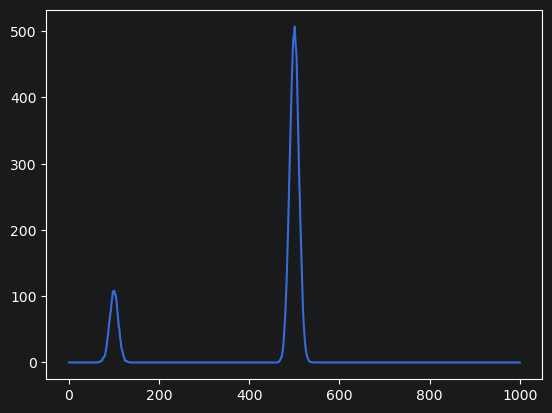

In [12]:
plt.plot(uniform_filter1d(counts, size=5))

In [17]:
peak_prominences(x=gaussian_smoothing(channels, domain.values, 10), peaks=[49])

/tmp/ipykernel_16824/624286886.py:1: PeakPropertyWarning: some peaks have a prominence of 0
  peak_prominences(x=gaussian_smoothing(channels, domain.values, 10), peaks=[49])


(array([0.]), array([49]), array([79]))

In [49]:
gaussian_smoothing(x, counts, 10)

array([11.56587449, 11.33072255, 11.05042465, ...,  8.39773265,
        7.94659808,  7.45205368], shape=(1001,))

In [45]:
gaussian_smoothing(x, counts, 10)[490]

np.float64(309.5254847155458)

In [46]:
y = domain.data.values
x= domain.data.coords[domain.spectrum.axis_name].values
dx = x[1] - x[0]
y = gaussian_smoothing(x, y, 20)
peak_indices = np.searchsorted(x, peaks)
widths, *_ = peak_widths(y, peak_indices, rel_height=0.5 )
widths

array([30.58633238])

In [22]:
y

array([  4.07700989,   5.06635111,   6.26697882,   7.71663051,
         9.45796184,  11.53690588,  14.00568558,  16.91972895,
        20.3378671 ,  24.32210948,  28.93656202,  34.24508124,
        40.31076504,  47.19286358,  54.94691509,  63.61998191,
        73.24938788,  83.859497  ,  95.46029352, 108.04354653,
       121.58312622, 136.03040528, 151.3142701 , 167.34175581,
       183.99493732, 201.13373572, 218.5964926 , 236.20213891,
       253.75236876, 271.0358404 , 287.83117165, 303.91223038,
       319.05263116, 333.03082691, 345.63534583, 356.66988695,
       365.95843938, 373.34945157, 378.72027568, 381.98022002,
       383.07308386, 381.97890745, 378.71449381, 373.33322467,
       365.92352653, 356.60669123, 345.53357573, 332.88082853,
       318.84597136, 303.64277977, 287.49565983, 270.63408936,
       253.28752349, 235.68027789, 218.02664219, 200.52664017,
       183.36315143, 166.69841154, 150.67224112, 135.40115841,
       120.97760355, 107.47006935,  94.92441124,  83.36

In [41]:
peak_indices

array([39])

In [15]:
fwhm_to_sigma(peak_fwhm(domain, smooth=True, prominence=1))

array([0.])

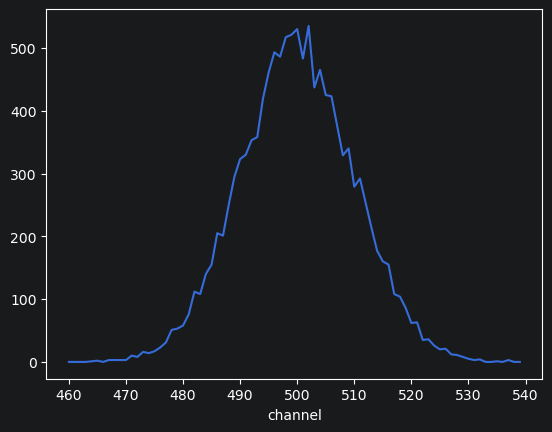

In [5]:
dom.plot()